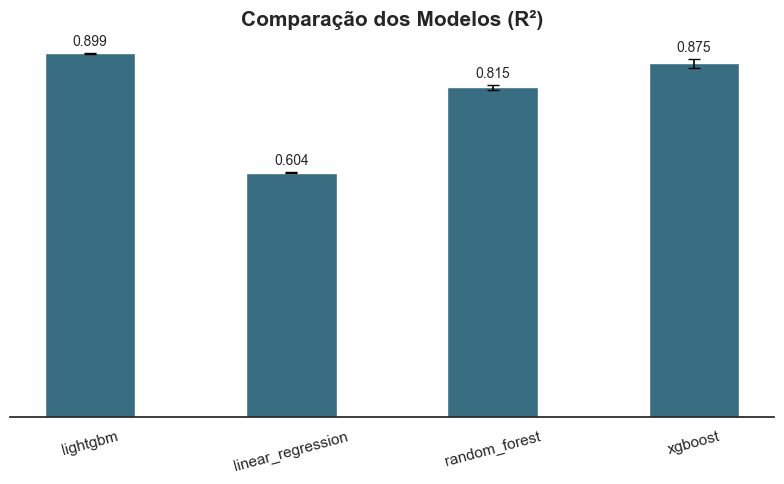

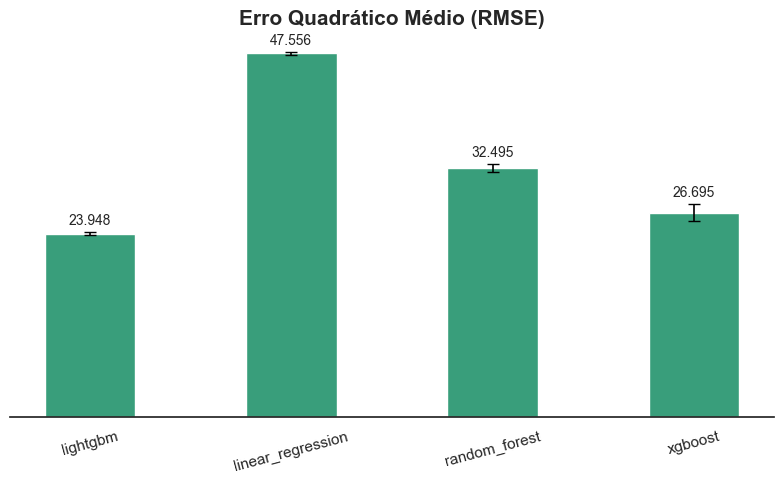

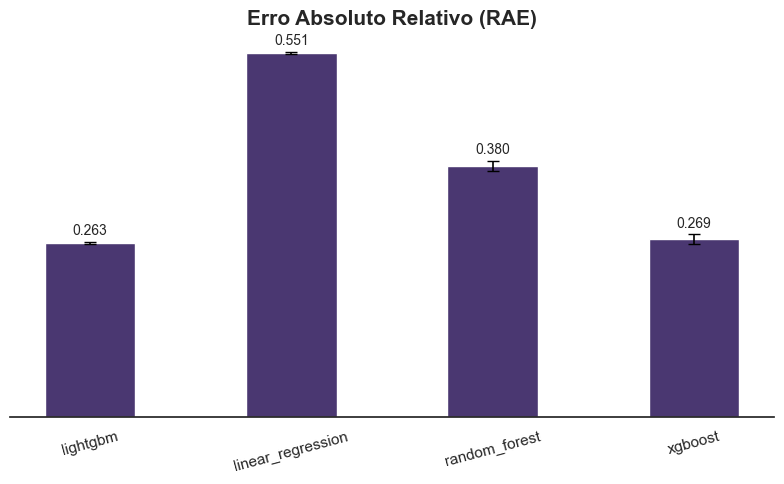

In [4]:
import os
import pickle
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

MODELS_DIR = "../models/pu-demand"

results = []

for model_name in os.listdir(MODELS_DIR):

    result_path = os.path.join(
        MODELS_DIR,
        model_name,
        "results.pkl"
    )

    if os.path.exists(result_path):

        with open(result_path, "rb") as f:
            metrics = pickle.load(f)

        metrics["Model"] = model_name

        results.append(metrics)

df = pd.DataFrame(results)

df.head()

sns.set_theme(style="white")

def plot_metric(df, metric, std, ylabel, title, color):

    plt.figure(figsize=(8,5))

    ax = sns.barplot(
        data=df,
        x="Model",
        y=metric,
        color=color,
        width=0.45
    )

    ax.errorbar(
        np.arange(len(df)),
        df[metric],
        yerr=df[std],
        fmt="none",
        ecolor="black",
        capsize=4,
        linewidth=1.2
    )

    # valor sobre cada barra
    for i, value in enumerate(df[metric]):
        ax.text(
            i,
            value + df[std].iloc[i] + 0.01 * df[metric].max(),
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=10
        )

    ax.set_title(title, fontsize=15, weight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")

    # Remove eixo Y
    ax.set_yticks([])
    ax.tick_params(axis="y", length=0)

    # Remove grid
    ax.grid(False)

    # Mantém apenas a linha inferior
    sns.despine(left=True)

    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()


# Cores da paleta viridis
palette = sns.color_palette("viridis", 7)

plot_metric(
    df,
    "r2_mean",
    "r2_std",
    "R²",
    "Comparação dos Modelos (R²)",
    palette[2]
)

plot_metric(
    df,
    "rmse_mean",
    "rmse_std",
    "RMSE",
    "Erro Quadrático Médio (RMSE)",
    palette[4]
)

plot_metric(
    df,
    "rae_mean",
    "rae_std",
    "RAE",
    "Erro Absoluto Relativo (RAE)",
    palette[0]
)

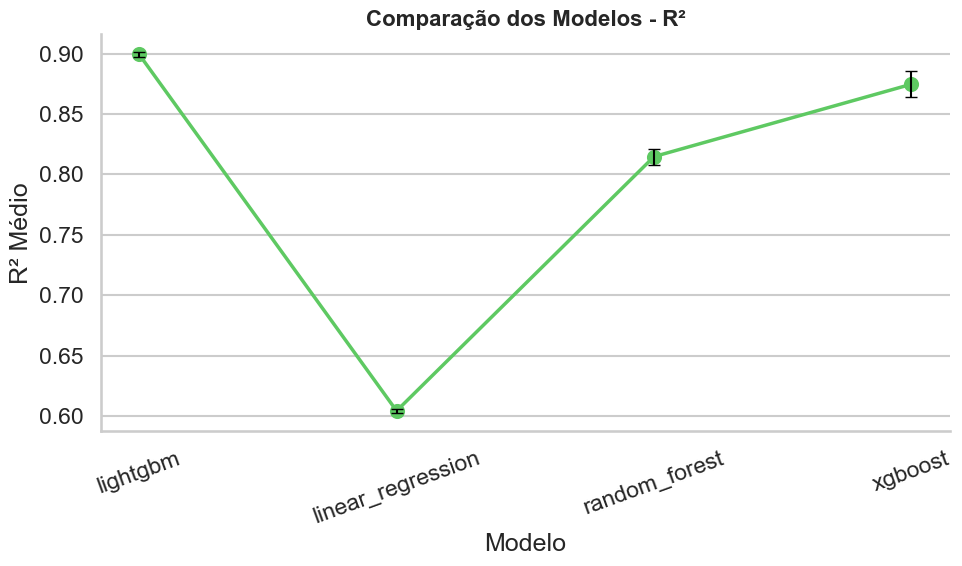

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(10, 6))

ax = sns.pointplot(
    data=df,
    x="Model",
    y="r2_mean",
    errorbar=None,
    color="#5ec962",
    markers="o",
    linestyles="-",
    linewidth=2.5,
    markersize=9
)

ax.errorbar(
    np.arange(len(df)),
    df["r2_mean"],
    yerr=df["r2_std"],
    fmt="none",
    color="black",
    capsize=4,
    linewidth=1.5
)

ax.set_title("Comparação dos Modelos - R²", fontsize=16, weight="bold")
ax.set_xlabel("Modelo")
ax.set_ylabel("R² Médio")

plt.xticks(rotation=20)
sns.despine()
plt.tight_layout()
plt.show()

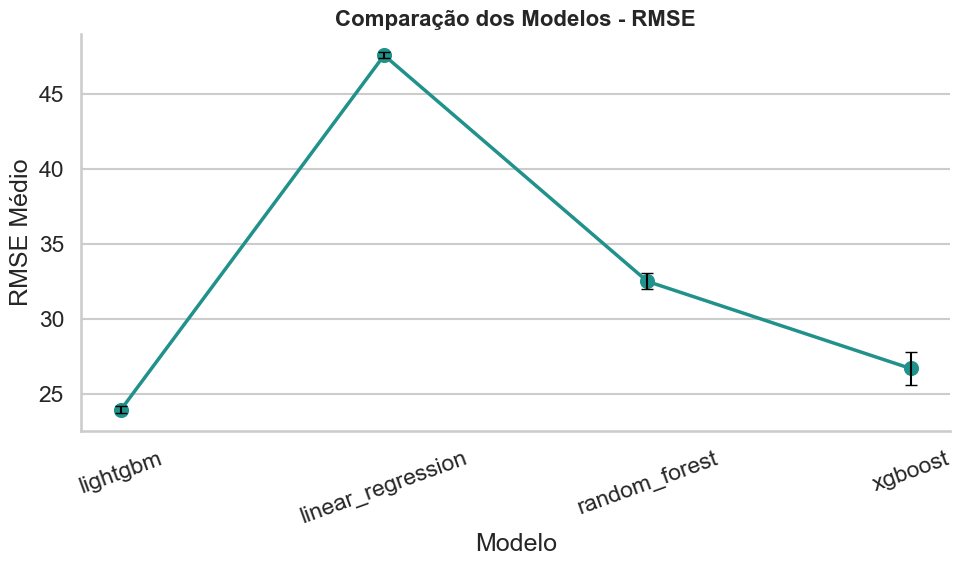

In [6]:
plt.figure(figsize=(10, 6))

ax = sns.pointplot(
    data=df,
    x="Model",
    y="rmse_mean",
    errorbar=None,
    color="#21918c",
    markers="o",
    linestyles="-",
    linewidth=2.5,
    markersize=9
)

ax.errorbar(
    np.arange(len(df)),
    df["rmse_mean"],
    yerr=df["rmse_std"],
    fmt="none",
    color="black",
    capsize=4,
    linewidth=1.5
)

ax.set_title("Comparação dos Modelos - RMSE", fontsize=16, weight="bold")
ax.set_xlabel("Modelo")
ax.set_ylabel("RMSE Médio")

plt.xticks(rotation=20)
sns.despine()
plt.tight_layout()
plt.show()

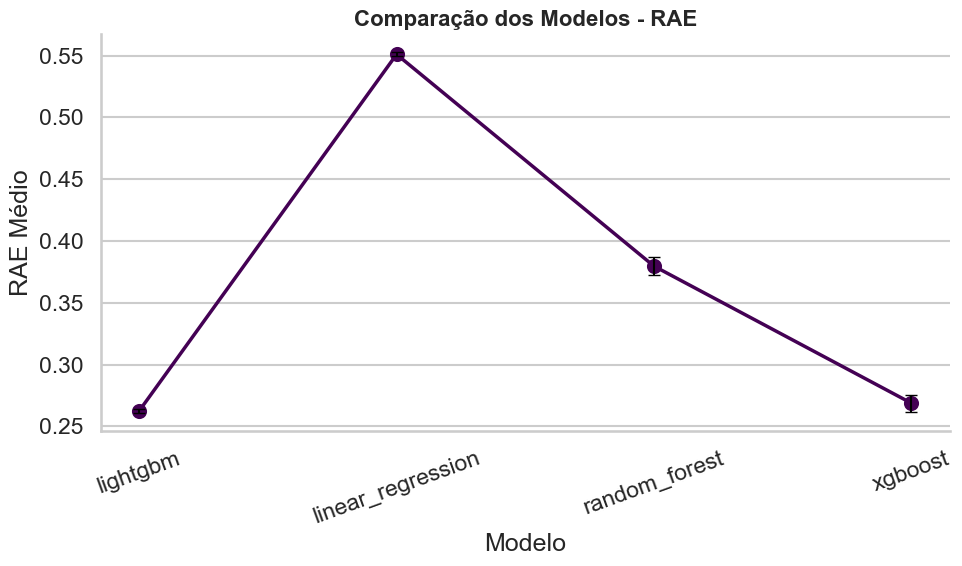

In [7]:
plt.figure(figsize=(10, 6))

ax = sns.pointplot(
    data=df,
    x="Model",
    y="rae_mean",
    errorbar=None,
    color="#440154",
    markers="o",
    linestyles="-",
    linewidth=2.5,
    markersize=9
)

ax.errorbar(
    np.arange(len(df)),
    df["rae_mean"],
    yerr=df["rae_std"],
    fmt="none",
    color="black",
    capsize=4,
    linewidth=1.5
)

ax.set_title("Comparação dos Modelos - RAE", fontsize=16, weight="bold")
ax.set_xlabel("Modelo")
ax.set_ylabel("RAE Médio")

plt.xticks(rotation=20)
sns.despine()
plt.tight_layout()
plt.show()